11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8633 - loss: 0.4763 - val_accuracy: 0.9582 - val_loss: 0.1415
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9648 - loss: 0.1218 - val_accuracy: 0.9687 - val_loss: 0.1028
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9754 - loss: 0.0800 - val_accuracy: 0.9727 - val_loss: 0.0933
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9830 - loss: 0.0551 - val_accuracy: 0.9722 - val_loss: 0.0993
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9866 - loss: 0.0415 - val_accuracy: 0.9753 - val_loss: 0.0913
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9896 - loss: 0.0321 - val_accuracy: 0.9710 - val_loss: 0.1135
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9907 - loss: 0.0295 - val_accuracy: 0.9749 - val_loss: 0.0931
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9935 - loss: 0.0202 - 

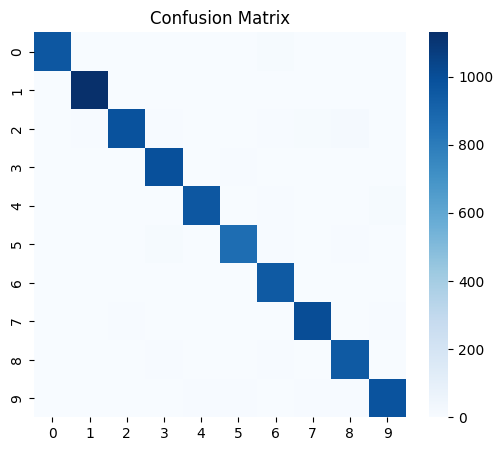


Experiment Completed Successfully ✅


In [1]:
# ============================
# EXPERIMENT 7
# Artificial Neural Network (ANN) using Keras
# ============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ----------------------------
# 1. Load Dataset (MNIST)
# ----------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

# ----------------------------
# 2. Preprocessing
# ----------------------------

# Normalize pixel values (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 images → 784 input features
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# ----------------------------
# 3. Build ANN Model
# ----------------------------

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# ----------------------------
# 4. Compile Model
# ----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# 5. Train Model
# ----------------------------

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ----------------------------
# 6. Evaluate Model
# ----------------------------

test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print("\nExperiment Completed Successfully ✅")